In [1]:
import pandas as pd
import numpy as np

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from umap import UMAP

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =====================================================
# 1. Chargement des données
# =====================================================

counts = pd.read_csv(
    "counts.tsv",
    sep="\t",
    index_col=0
)

print("Matrice brute :", counts.shape)

Matrice brute : (41130, 175)


In [3]:
# =====================================================
# 2. Filtrage des gènes peu exprimés
# =====================================================

MIN_COUNTS = 10
MIN_SAMPLE_FRAC = 0.20

min_samples = max(
    2,
    int(np.ceil(MIN_SAMPLE_FRAC * counts.shape[1]))
)

keep = (
    (counts >= MIN_COUNTS)
    .sum(axis=1)
    >= min_samples
)

# PyDESeq2 expects int -> also cast all columns
counts_filt = counts.loc[keep].map(int)

print(
    f"Gènes après filtrage : "
    f"{counts_filt.shape[0]}"
)

Gènes après filtrage : 20649


In [4]:
# =====================================================
# 3. Préparation pour PyDESeq2
# =====================================================

# PyDESeq2 attend :
# samples x genes

counts_for_deseq = counts_filt.T

metadata = pd.DataFrame(
    {
        "condition": ["all"] * counts_for_deseq.shape[0]
    },
    index=counts_for_deseq.index
)

In [8]:
# =====================================================
# 4. Estimation des size factors DESeq2
# =====================================================

inference = DefaultInference(n_cpus=8)

dds = DeseqDataSet(
    counts=counts_for_deseq,
    metadata=metadata,
    design="~condition",
    refit_cooks=True,
    inference=inference,
    quiet=False,
)

dds.fit_size_factors()


# comptes normalisés DESeq2
#norm_counts = dds.layers["normed_counts"]

# BETTER: Use pyDESeq2's VST (Variance Stabilizing Transformation)
dds.vst()
norm_counts = dds.layers["vst_counts"]

norm_counts = pd.DataFrame(
    norm_counts,
    index=counts_for_deseq.index,
    columns=counts_for_deseq.columns
)

print(
    "Matrice normalisée :",
    norm_counts.shape
)

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.34 seconds.

Fitting size factors...


Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


... done in 0.27 seconds.

Fitting dispersions...
... done in 6.71 seconds.



Matrice normalisée : (175, 20649)


In [9]:
# =====================================================
# 5. Log-transformation
# =====================================================

# OLD: log-transform
#log_expr = np.log2(norm_counts + 1)

# BETTER: Use pyDESeq2's VST (Variance Stabilizing Transformation)
log_expr = norm_counts

In [10]:
# =====================================================
# 6. Sélection des gènes les plus variables
# =====================================================

N_VARIABLE_GENES = 5000

gene_variance = log_expr.var(axis=0)

n_keep = min(
    N_VARIABLE_GENES,
    len(gene_variance)
)

top_genes = (
    gene_variance
    .nlargest(n_keep)
    .index
)

expr_var = log_expr[top_genes]

print(
    f"Gènes variables conservés : "
    f"{expr_var.shape[1]}"
)

Gènes variables conservés : 5000


In [11]:
# =====================================================
# 7. Standardisation
# =====================================================

expr_scaled = (
    expr_var
    - expr_var.mean(axis=0)
) / (
    expr_var.std(axis=0) + 1e-8
)

# Write filt+norm file:
counts_filt.to_csv("counts_norm.tsv", sep="\t")
print("Wrote: 'counts_norm.tsv'")

Wrote: 'counts_norm.tsv'


In [12]:
# =====================================================
# 8. PCA
# =====================================================

pca = PCA(
    n_components=20,
    random_state=42
)

pcs = pca.fit_transform(expr_scaled)

print(
    "Variance expliquée PC1 :",
    round(
        pca.explained_variance_ratio_[0] * 100,
        2
    ),
    "%"
)

print(
    "Variance expliquée PC2 :",
    round(
        pca.explained_variance_ratio_[1] * 100,
        2
    ),
    "%"
)

print("Total variance explained:", sum(pca.explained_variance_ratio_)*100)

Variance expliquée PC1 : 25.59 %
Variance expliquée PC2 : 15.39 %
Total variance explained: 69.48308321075588


# =====================================================
# 9. Figure PCA
# =====================================================

plt.figure(figsize=(8,6))

plt.scatter(
    pcs[:,0],
    pcs[:,1],
    s=80
)

for i, sample in enumerate(expr_scaled.index):
    plt.annotate(
        sample,
        (pcs[i,0], pcs[i,1]),
        fontsize=8
    )

plt.title("PCA")

plt.tight_layout()

plt.show()

# =====================================================
# 10. UMAP
# =====================================================

umap = UMAP(
    n_neighbors=10,
    min_dist=0.3,
    metric="euclidean",
    random_state=42
)

embedding = umap.fit_transform(pcs)


plt.figure(figsize=(8,6))

plt.scatter(
    embedding[:,0],
    embedding[:,1],
    s=80
)

for i, sample in enumerate(expr_scaled.index):
    plt.annotate(
        sample,
        (
            embedding[i,0],
            embedding[i,1]
        ),
        fontsize=8
    )

plt.title("UMAP")

plt.tight_layout()

plt.show()

In [13]:
# =====================================================
# 11. Recherche du nombre optimal de clusters
# =====================================================

sil_scores = {}

for k in range(2, 10):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=50
    )

    labels = km.fit_predict(pcs)

    sil = silhouette_score(
        pcs,
        labels
    )

    sil_scores[k] = sil


best_k = max(
    sil_scores,
    key=sil_scores.get
)

print(
    "\nNombre optimal de clusters :",
    best_k
)

print(
    "Score silhouette :",
    sil_scores[best_k]
)


Nombre optimal de clusters : 2
Score silhouette : 0.5922970518990035


In [14]:
# =====================================================
# 12. Clustering final
# =====================================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=50
)

clusters = kmeans.fit_predict(pcs)

cluster_table = pd.DataFrame(
    {
        "sample": expr_scaled.index,
        "cluster": clusters + 1
    }
)

print(cluster_table)

          sample  cluster
0    SRR14863992        1
1    SRR14863842        2
2    SRR14863908        1
3    SRR14863848        2
4    SRR14863849        2
..           ...      ...
170  SRR14863994        1
171  SRR14863917        1
172  SRR14863931        1
173  SRR14863999        1
174  SRR14863965        1

[175 rows x 2 columns]


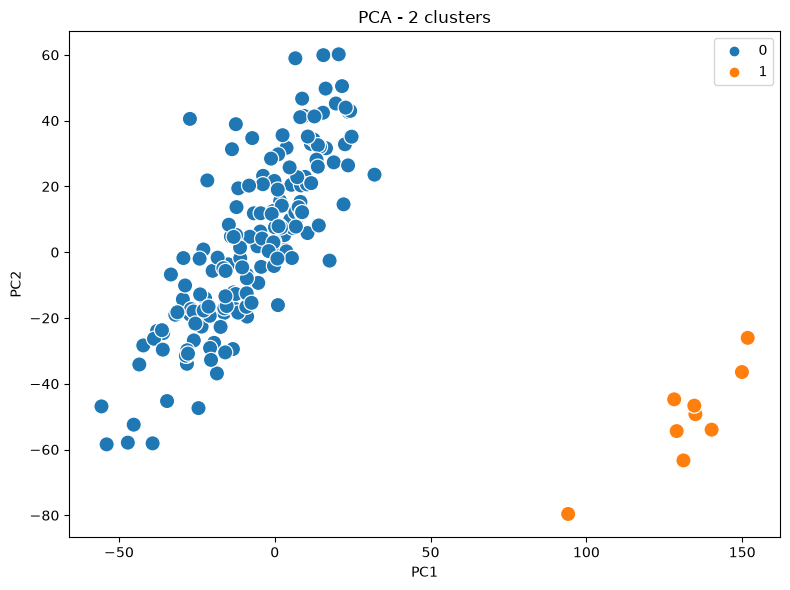

In [15]:
# =====================================================
# 13. PCA colorée par cluster
# =====================================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pcs[:,0],
    y=pcs[:,1],
    hue=clusters,
    palette="tab10",
    s=120
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title(
    f"PCA - {best_k} clusters"
)

plt.tight_layout()

plt.show()